# ClusterGuard 분석 플로우

Kafka slowlog 한 건이 리포트가 되기까지.

**1번 그림만 손으로 그렸다.** 2번부터는 실제로 조립한 Agent에서 읽는다 —
그래프 모양도, 모델이 받는 도구 목록도, 상한 값도 런타임 객체에서 나온다.
코드가 바뀌면 다시 돌렸을 때 출력도 바뀐다.


## 1. 전체 흐름  (개념도)


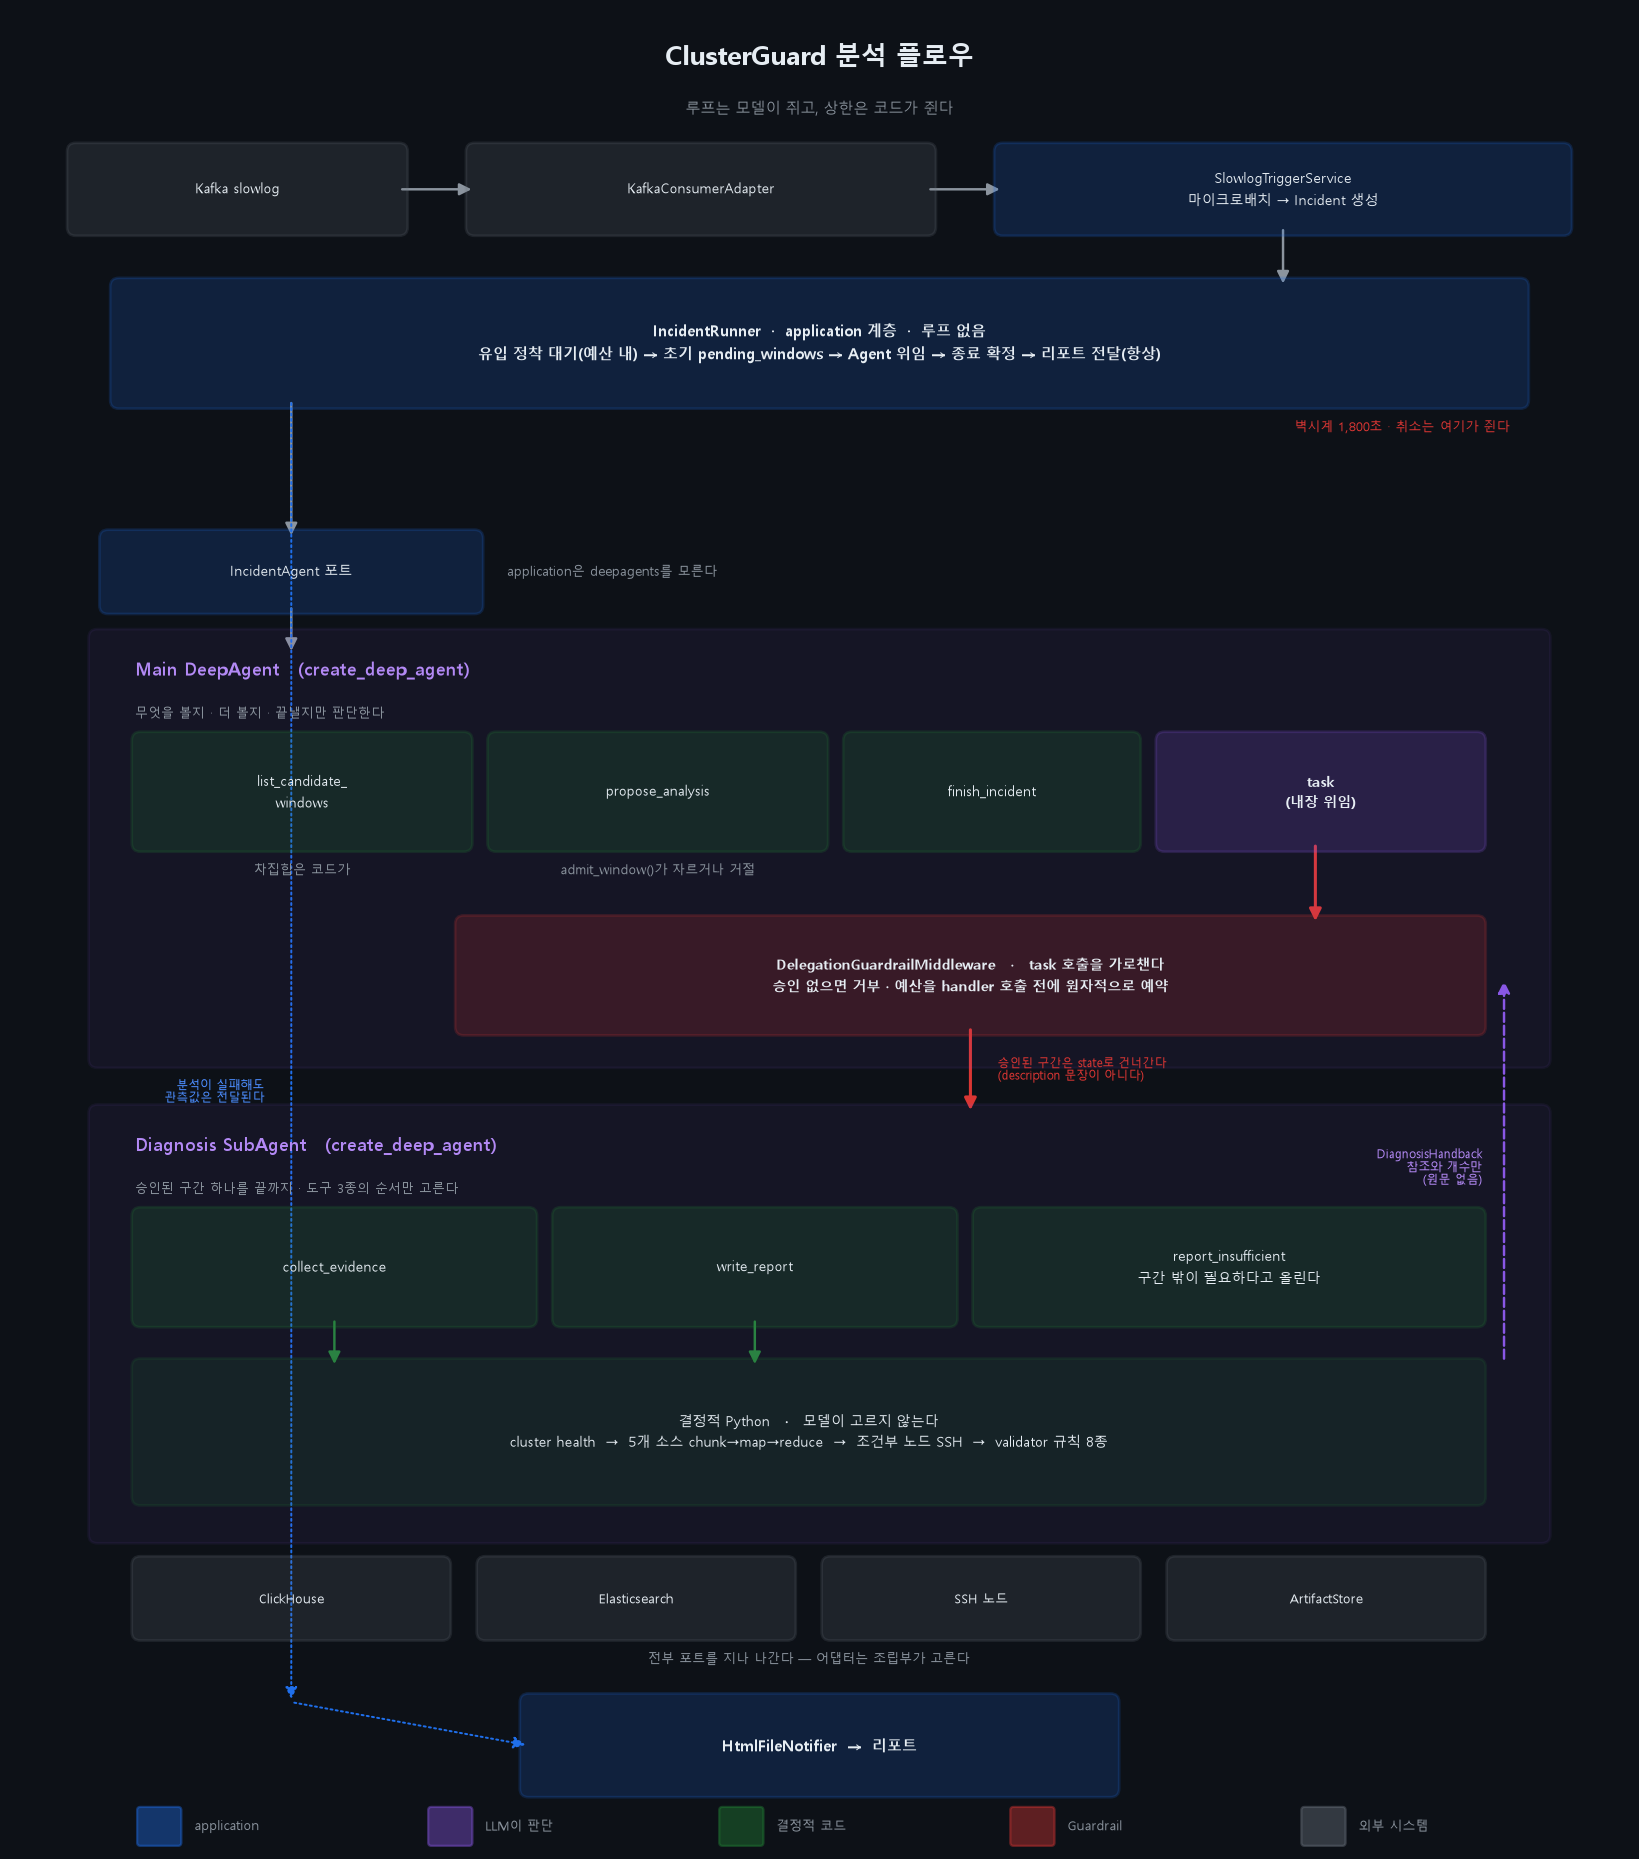

In [ ]:
# 이 셀만 손으로 그린 그림이다. 나머지는 코드에서 읽는다.
from IPython.display import Image, display
display(Image(filename='flow_overview.png')) if __import__('pathlib').Path('flow_overview.png').exists() else None


## 2. 실제 Agent 조립


In [ ]:
"""실제 Agent를 조립한다. LLM·ClickHouse·SSH는 가짜로 대신한다.

구조를 보는 것이 목적이라 모델은 아무 말도 하지 않는 가짜면 된다.
그래프의 모양과 도구 목록은 모델이 무엇을 답하든 같다.
"""
import sys
from pathlib import Path
from unittest.mock import MagicMock

ROOT = Path.cwd().parent if Path.cwd().name == "tests" else Path.cwd()
sys.path[:0] = [str(ROOT / "src"), str(ROOT / "tests")]

from langchain_core.language_models.fake_chat_models import FakeMessagesListChatModel
from langchain_core.messages import AIMessage

from cluster_doctor.domain.model.incident import Incident
from cluster_doctor.domain.model.incident_state import IncidentState
from cluster_doctor.infrastructure.outbound.agent.common.kst import parse_kst
from cluster_doctor.infrastructure.outbound.agent.diagnosis.report_writer import ReportWriter
from cluster_doctor.infrastructure.outbound.agent.diagnosis.subagent import (
    DiagnosisSeams, build_diagnosis_subagent,
)
from cluster_doctor.infrastructure.outbound.agent.supervisor.guardrail_middleware import (
    DelegationGuardrailMiddleware,
)
from cluster_doctor.infrastructure.outbound.agent.supervisor.main_agent import build_main_agent
from cluster_doctor.infrastructure.outbound.agent.supervisor.state import (
    ADMITTED_GOAL, ADMITTED_WINDOW, CLUSTER, INCIDENT_ID,
)
from cluster_doctor.infrastructure.outbound.agent.supervisor.tools import (
    make_finish_incident_tool, make_list_candidate_windows_tool, make_propose_analysis_tool,
)
from cluster_doctor.infrastructure.outbound.memory.in_memory_artifact_store import (
    InMemoryArtifactStore,
)
from cluster_doctor.infrastructure.outbound.memory.in_memory_incident_state_repository import (
    InMemoryIncidentStateRepository,
)

seen_tools = []


class Spy(FakeMessagesListChatModel):
    """모델에게 건네진 도구 목록을 받아 적는 가짜 모델."""

    def bind_tools(self, tools, **kw):
        seen_tools.append(sorted(getattr(t, "name", str(t)) for t in tools))
        return self.bind(**kw)


def assemble():
    store = InMemoryArtifactStore()
    repo = InMemoryIncidentStateRepository()
    state = IncidentState(incident_id="demo")
    repo.create(state)
    incident = Incident(
        incident_id="demo", cluster="es-prod",
        trigger_time=parse_kst("2026-09-21 14:00:00"),
        kafka_receive_time=parse_kst("2026-09-21 14:00:00"),
    )
    model = Spy(responses=[AIMessage(content="끝")] * 8)
    seams = DiagnosisSeams(
        store=store, fetch_logs=lambda w: [], fetch_node_logs=lambda **kw: [],
        cluster=MagicMock(), node_resolver=MagicMock(), node_log_fetcher=MagicMock(),
        call_llm=lambda *a, **k: "{}",
        report_writer=ReportWriter(store=store, call_llm=lambda *a, **k: "{}"),
    )
    diagnosis = build_diagnosis_subagent(
        seams=seams, state=state, repository=repo, incident=incident, model=model
    )
    main = build_main_agent(
        model=model,
        tools=[
            make_list_candidate_windows_tool(state=state),
            make_propose_analysis_tool(state=state, repository=repo),
            make_finish_incident_tool(state=state, repository=repo),
        ],
        middleware=[DelegationGuardrailMiddleware(state=state, repository=repo)],
        diagnosis_subagent=diagnosis,
    )
    return main, diagnosis, state, repo


main, diagnosis, state, repo = assemble()
print("조립 완료 —", type(main).__name__)


조립 완료 — CompiledStateGraph


## 3. Main DeepAgent 그래프

`get_graph().to_json()`이 돌려준 노드와 엣지를 그대로 그린다.
`after_model` 훅이 보이는데, 이것이 연속 거절 상한을 집행하고
동시에 `model` 분기를 라우팅 가능하게 만든다.


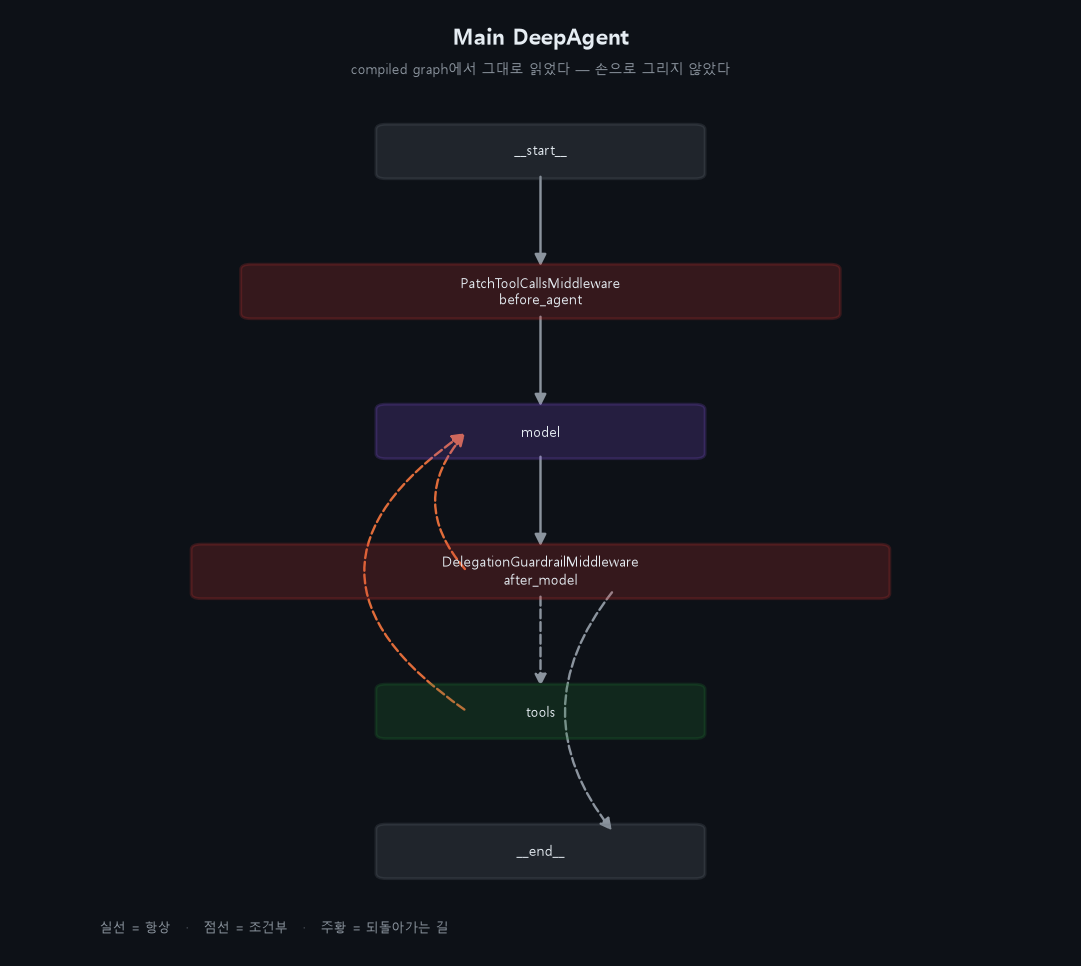

In [ ]:
"""Main DeepAgent 그래프. compiled graph에서 노드와 엣지를 그대로 읽는다."""
from graph_viz import draw_graph

draw_graph(main, "Main DeepAgent", "compiled graph에서 그대로 읽었다")


## 4. Diagnosis SubAgent 그래프

Main과 달리 `after_model` 훅이 없다 — 예산은 이미 위임 시점에 예약됐고,
이 안에서는 도구 3종의 순서만 정해진다.


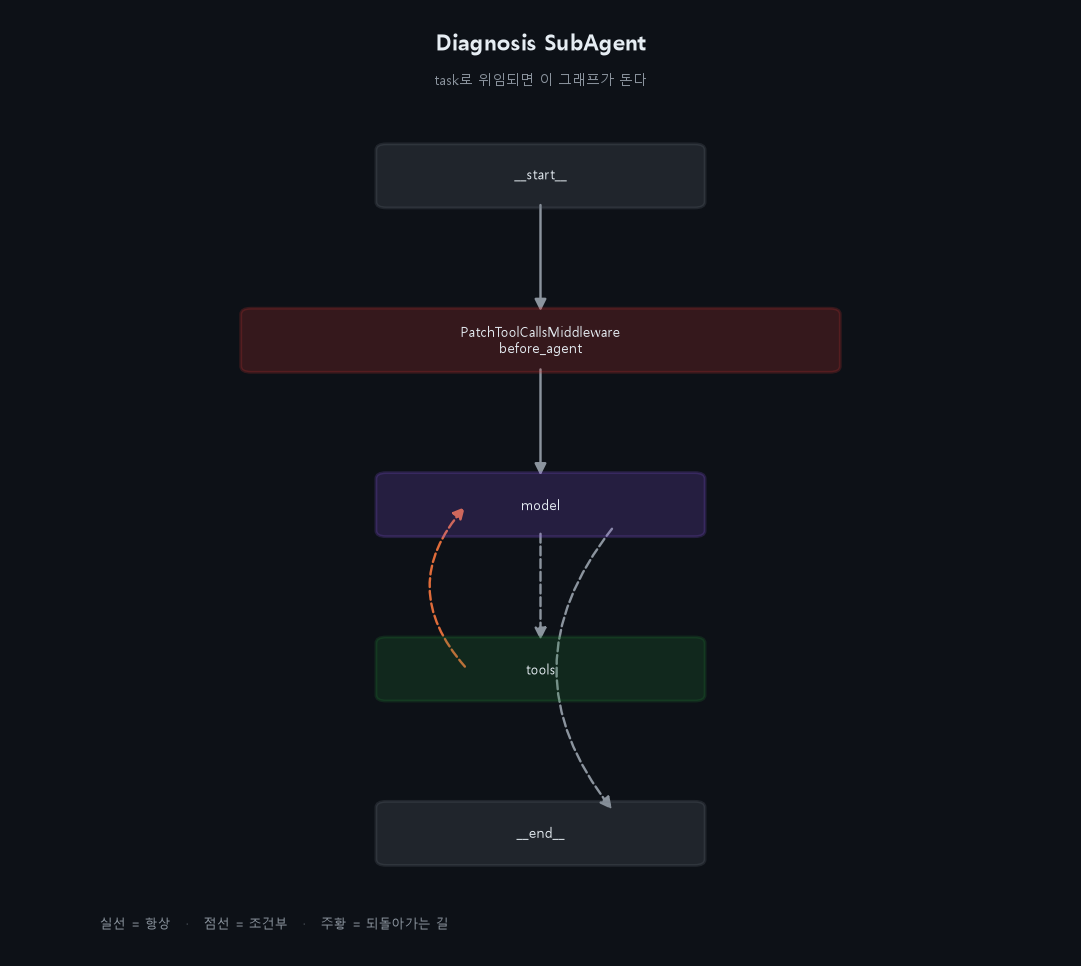

In [ ]:
"""Diagnosis SubAgent 그래프.

내부 그래프라 밖에서 잡히지 않는다 — ``create_deep_agent``이 위임을 받은
뒤에야 불리기 때문이다. 감싸서 실제로 컴파일된 것을 받아 둔다. 재현이 아니라
그때 돈 바로 그 그래프다.
"""
import cluster_doctor.infrastructure.outbound.agent.diagnosis.subagent as S

captured = {}
_orig = S.create_deep_agent
S.create_deep_agent = lambda *a, **kw: captured.setdefault("g", _orig(*a, **kw))
try:
    main2, diagnosis2, _, _ = assemble()
    diagnosis2["runnable"].invoke({
        "messages": [("user", "분석")], INCIDENT_ID: "demo", CLUSTER: "es-prod",
        ADMITTED_WINDOW: {"start": "2026-09-21T14:00:00", "end": "2026-09-21T14:05:00"},
        ADMITTED_GOAL: "heap 상승 확인",
    })
finally:
    S.create_deep_agent = _orig

draw_graph(captured["g"], "Diagnosis SubAgent", "task로 위임되면 이 그래프가 돈다")


## 5. 모델이 실제로 받는 도구


In [ ]:
"""모델이 실제로 받는 도구 목록.

``create_deep_agent``은 부르기만 하면 ls·read_file·write_file·edit_file·
delete·glob·grep·execute를 함께 묶어 준다. 두 Agent 모두 그것을 떼어 냈는지
손으로 적은 목록이 아니라 런타임에서 확인한다.
"""
HARNESS = {"ls", "read_file", "write_file", "edit_file", "delete", "glob", "grep", "execute"}

seen_tools.clear()
m3, d3, s3, r3 = assemble()
m3.invoke({
    "messages": [("user", "시작")], INCIDENT_ID: "demo", CLUSTER: "es-prod",
    ADMITTED_WINDOW: None, ADMITTED_GOAL: "", "last_response": None,
})
main_tools = seen_tools[0]

seen_tools.clear()
d3["runnable"].invoke({
    "messages": [("user", "분석")], INCIDENT_ID: "demo", CLUSTER: "es-prod",
    ADMITTED_WINDOW: {"start": "2026-09-21T14:00:00", "end": "2026-09-21T14:05:00"},
    ADMITTED_GOAL: "heap 상승 확인",
})
diagnosis_tools = seen_tools[0] if seen_tools else []

for title, tools in [("Main DeepAgent", main_tools), ("Diagnosis SubAgent", diagnosis_tools)]:
    leaked = sorted(set(tools) & HARNESS)
    print(title)
    for name in tools:
        print(f"    {name}")
    print(f"    └ 셸·파일 도구 노출: {', '.join(leaked) if leaked else '없음'}")
    print()


Main DeepAgent
    finish_incident
    list_candidate_windows
    propose_analysis
    task
    └ 셸·파일 도구 노출: 없음

Diagnosis SubAgent
    collect_evidence
    report_insufficient
    write_report
    └ 셸·파일 도구 노출: 없음



## 6. 상한과 그 강제 위치


In [ ]:
"""상한과 그 강제 위치. 값은 실제 상수에서 읽는다."""
from cluster_doctor.application.service import guardrails as G
from cluster_doctor.domain.model.time_range import MAX_TIME_RANGE_DURATION
from cluster_doctor.infrastructure.outbound.agent.diagnosis.subagent import _MAX_REPORT_ATTEMPTS

rows = [
    ("분석 예산 (분)", G.MAX_ANALYZED_MINUTES, "DelegationGuardrailMiddleware.wrap_tool_call"),
    ("분석 호출 수", G.MAX_ANALYSIS_CALLS, "DelegationGuardrailMiddleware.wrap_tool_call"),
    ("단일 구간 길이 (분)", int(MAX_TIME_RANGE_DURATION.total_seconds() // 60), "TimeRange.__post_init__"),
    ("연속 거절", G.MAX_REJECTED_DECISIONS, "DelegationGuardrailMiddleware.after_model"),
    ("리포트 수정", G.MAX_REPORT_REVISIONS, "ReportWriter.verify_and_revise"),
    ("리포트 재작성", _MAX_REPORT_ATTEMPTS, "diagnosis/subagent.write_report"),
    ("Incident 실행 시간 (초)", int(G.INCIDENT_TIMEOUT_SECONDS), "IncidentRunner._run_agent"),
    ("유입 누적 대기 (초)", int(G.MAX_TOTAL_WAIT_SECONDS), "guardrails.clamp_wait"),
    ("Evidence 총량", G.MAX_EVIDENCE_TOTAL, "collector.collect"),
]
width = max(len(r[0]) for r in rows)
print(f"{'상한':<{width}}  {'값':>6}   강제 위치")
print("─" * (width + 52))
for name, value, where in rows:
    print(f"{name:<{width}}  {value:>6}   {where}")
print()
print("전부 프롬프트 문장이 아니라 코드다.")


상한                       값   강제 위치
──────────────────────────────────────────────────────────────────────
분석 예산 (분)               60   DelegationGuardrailMiddleware.wrap_tool_call
분석 호출 수                 12   DelegationGuardrailMiddleware.wrap_tool_call
단일 구간 길이 (분)            10   TimeRange.__post_init__
연속 거절                    3   DelegationGuardrailMiddleware.after_model
리포트 수정                   1   ReportWriter.verify_and_revise
리포트 재작성                  2   diagnosis/subagent.write_report
Incident 실행 시간 (초)    1800   IncidentRunner._run_agent
유입 누적 대기 (초)           300   guardrails.clamp_wait
Evidence 총량             80   collector.collect

전부 프롬프트 문장이 아니라 코드다.
